Submitted by : Anupriya Dhiman

Python Q&A assignment
**Purpose:** This notebook fine-tunes a compact GPT-2 style language model to answer *only* Python coding questions using the **Dataset_Python_Question_Answer** Kaggle dataset. It covers data loading, preprocessing/tokenization, model configuration, custom training, checkpointing, and inference with a Python-only filtering mechanism.

## What this notebook does
1. **Setup (Colab + Dependencies):** Mount Google Drive for persistent storage and import core libraries (`transformers`, `datasets`, `torch`, `kagglehub`, etc.).
2. **Data:** Load `chinmayadatt/dataset-python-question-answer` via KaggleHub and perform lightweight preprocessing/tokenization suitable for QA-style language modeling.
3. **Model:** Initialize a small GPT-2 configuration (tokenizer + `GPT2LMHeadModel`) tailored for fast prototyping on limited resources.
4. **Training Loop:** Train with `AdamW`, gradient clipping, and mini-batches using `DataLoader`/`Dataset`; track loss and save periodic checkpoints.
5. **Logging & Plots:** Record training history (loss) and visualize progression to validate convergence.
6. **Checkpointing:** Persist tokenizer/model to Drive for later reuse and reproducibility.
7. **Inference with Filtering:** Load a chosen checkpoint and implement a Python-coding question filter — if a prompt is Python-related, generate an answer; otherwise return a polite refusal.

## Why Dataset_Python_Question_Answer?
This dataset contains curated Python programming Q&A pairs, making it ideal for training a domain-specific language model that should respond only to coding-related queries.

## Requirements
- Python 3.x, PyTorch, Transformers, KaggleHub, TQDM, Matplotlib
- Sufficient GPU (e.g., Colab T4/A100) recommended



### 1. Google Drive Mount

Mounts Google Drive in Colab to access and save files directly from your Drive.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Library Installation and Data Loading

- Installs the **`datasets`** and **`kagglehub`** libraries.
- Suppresses warning messages for cleaner output.
- Imports essential libraries for data handling, tokenization, visualization, and model building.
- Loads the **Dataset_Python_Question_Answer** dataset from Kaggle using KaggleHub.


In [2]:
# !pip install datasets kagglehub

import warnings
warnings.filterwarnings("ignore")

import re
import torch
import random
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import GPT2Tokenizer
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Dataset_Python_Question_Answer.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "chinmayadatt/dataset-python-question-answer",
    file_path,
)

print("First 5 records:")
df.head()

100%|██████████| 704k/704k [00:00<00:00, 2.60MB/s]

First 5 records:


,Question,Answer
0,What is the difference between a variable and...,"[""Sure, here's the difference between a variab..."
1,What is the difference between a built-in fun...,"[""Sure. Here's the difference between built-in..."
2,What is the difference between the `print` fu...,"[""Sure. Here's the difference between the two ..."
3,What is the difference between an expression ...,"[""Sure! Here's the difference between an expre..."
4,What is the difference between `True` and `Fa...,"[""Sure. Here's the difference between `True` a..."


In [11]:
df.iloc[0]

,0
Question,What is the difference between a variable and...
Answer,"[""Sure, here's the difference between a variab..."


### 3. PythonQADataset Class

- Creates a **PyTorch dataset** for Python Q&A text formatted as `Question: ... Answer: ...`.
- Steps performed for each row:
  1. **Format text:** Combines the `Question` and `Answer` columns into a single prompt string.
  2. **Skip short samples:** Entries shorter than `min_length` characters are ignored.
  3. **Clean text:**
     - Removes extra spaces and unwanted characters.
     - Normalises fancy quotes to standard ASCII quotes.
  4. **Tokenize:** Converts the formatted text into token IDs using a GPT-2 tokenizer.
  5. **Prepare training inputs:**
     - `input_ids`: All tokens except the last one.
     - `labels`: All tokens except the first one (for next-token prediction).
     - `attention_mask`: Marks which tokens are real vs. padding.



In [3]:
from torch.utils.data import Dataset

class PythonQADataset(Dataset):
    def __init__(self, dataframe, tokenizer, block_size=256, min_length=30):
        self.tokenizer = tokenizer
        self.block_size = block_size
        self.samples = []

        for _, row in dataframe.iterrows():
            # Combine question and answer columns into a single training string
            question = str(row.get('Question', row.iloc[0])).strip()
            answer   = str(row.get('Answer',   row.iloc[1])).strip()
            text = f"Question: {question} Answer: {answer}"

            if len(text) < min_length:
                continue

            # Clean text
            text = re.sub(r'\s+', ' ', text)
            text = re.sub(r'[\u201c\u201d]', '"', text)
            text = re.sub(r"[\u2018\u2019]", "'", text)
            text = re.sub(r'[^a-zA-Z0-9_.,!?\'"\(\)\[\]\{\}:#=+\-*/\\\s]', '', text)

            tokenized = self.tokenizer(
                text,
                truncation=True,
                add_special_tokens=True,
                padding="max_length",
                max_length=self.block_size,
                return_tensors="pt"
            )

            input_ids      = tokenized["input_ids"][0]
            attention_mask = tokenized["attention_mask"][0]

            self.samples.append({
                "input_ids":      input_ids[:-1],
                "labels":         input_ids[1:],
                "attention_mask": attention_mask[:-1]
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

### 4. Load Tokenizer, DataLoader, Model, and Optimizer Setup

1. **Training size & batching**
   - Define `batch_size`; compute `max_batches_per_epoch` from dataset length.

2. **Tokenizer**
   - Load GPT-2 tokenizer and set the **pad token** to EOS for consistent padding.

3. **Dataset → DataLoader**
   - Wrap `PythonQADataset` with a `DataLoader` to yield mini-batches for training.

4. **Model configuration**
   - Build a **small GPT-2**:
     - `vocab_size = len(tokenizer)`
     - Context length: `n_positions = n_ctx = 256`
     - Model width: `n_embd = 256`
     - Depth/heads: `n_layer = 4`, `n_head = 4`
     - Use tokenizer's `pad_token_id`

5. **Device placement**
   - Move model to **GPU** if available; enable **DataParallel** when multiple GPUs exist.

6. **Optimizer**
   - Initialize **AdamW** with learning rate `5e-4` (higher than the story notebook because the Python QA dataset is much smaller).

In [4]:
from transformers import GPT2Tokenizer
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import GPT2Config, GPT2LMHeadModel
from tqdm.auto import tqdm
import torch


tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token


batch_size = 16
qa_dataset = PythonQADataset(df, tokenizer, block_size=256)
train_loader = DataLoader(qa_dataset, batch_size=batch_size, shuffle=True)

total_samples        = len(qa_dataset)
max_batches_per_epoch = total_samples // batch_size
print(f"Total QA samples : {total_samples}")
print(f"Max batches/epoch: {max_batches_per_epoch}")

config = GPT2Config(
    vocab_size= len(tokenizer),
    n_positions= 256,
    n_ctx= 256,
    n_embd= 256,
    n_layer = 4,
    n_head= 4,
    pad_token_id = tokenizer.pad_token_id
)

model  = GPT2LMHeadModel(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = torch.nn.DataParallel(model)

optimizer = AdamW(model.parameters(), lr=5e-4)

print(f"Model parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"Device           : {device}")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Total QA samples : 419
Max batches/epoch: 26
Model parameters : 16,090,880
Device           : cpu


### 5. Training Loop, Checkpointing, and Sampling

1. **Setup**
   - Define a checkpoint folder on Google Drive.
   - Set number of epochs and initialise a loss history list.
   - Switch model to training mode.

2. **Epoch training**
   - For each epoch:
     - Iterate over mini-batches up to `max_batches_per_epoch`.
     - Move tensors to the selected device (CPU/GPU).
     - Forward pass → compute loss.
     - Backward pass with gradient clipping (max norm = 1.0).
     - Optimizer step.

3. **Checkpoint each epoch**
   - Save model and tokenizer to `pythongpt2_epochN` after every epoch.

4. **Quick qualitative check**
   - Switch to eval, generate a short Python Q&A continuation, print sample, return to train mode.

5. **Save history**
   - Persist epoch-average losses to `training_history.json` on Drive.

In [5]:
from pathlib import Path
import json
from tqdm.auto import tqdm
from torch.nn.utils import clip_grad_norm_


checkpoint_dir = Path("/content/drive/MyDrive/PythonGPT/model/")

epochs  = 10
history = []

model.train()

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs}")
    epoch_loss = 0.0

    for i, batch in enumerate(tqdm(train_loader, total=max_batches_per_epoch)):
        if i >= max_batches_per_epoch:
            break

        input_ids= batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids = input_ids,
            labels = labels,
            attention_mask = attention_mask
        )
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / max(max_batches_per_epoch, 1)
    history.append(avg_loss)
    print(f"Average Loss: {avg_loss:.4f}")


    epoch_checkpoint = checkpoint_dir / f"pythongpt2_epoch{epoch + 1}"
    epoch_checkpoint.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(epoch_checkpoint)
    tokenizer.save_pretrained(epoch_checkpoint)
    print(f"Model checkpoint saved at {epoch_checkpoint}")

    model.eval()
    sample_input = tokenizer.encode(
        "Question: How do you write a for loop in Python? Answer:",
        return_tensors="pt"
    ).to(device)

    generated_ids = model.generate(
        sample_input,
        max_length = 80,
        num_return_sequences= 1,
        no_repeat_ngram_size = 2,
        pad_token_id= tokenizer.pad_token_id,
        eos_token_id = tokenizer.eos_token_id
    )
    generated_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    print(f"Sample Output:\n{generated_text}")
    model.train()

history_path = Path("/content/drive/MyDrive/PythonGPT/training_history.json")
history_path.parent.mkdir(parents=True, exist_ok=True)
with open(history_path, "w") as f:
    json.dump(history, f)
print(f"\nTraining history saved to {history_path}")


Epoch 1/10


  0%|          | 0/26 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Average Loss: 8.4783


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Model checkpoint saved at /content/drive/MyDrive/PythonGPT/model/pythongpt2_epoch9
Sample Output:
Question: How do you write a for loop in Python? Answer:Sure Here a-- example**:',- guide how use to a in: '. '1 ** the of that a:** ' ****.ineing**** a that you to the.' ' The of.' "- can used create list,- a.'',**',* ** a object,**-

Epoch 10/10


  0%|          | 0/26 [00:00<?, ?it/s]

Average Loss: 3.7349


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model checkpoint saved at /content/drive/MyDrive/PythonGPT/model/pythongpt2_epoch10
Sample Output:
Question: How do you write a for loop in Python? Answer:Sure Here a of to a-- guide how can used create list Python: '.ine function a:',- the of. ' It a to the. the toate a.' ' The() to multiple of that the is to specific. can the.' "'s to.' "- the and.' Output', - the,

Training history saved to /content/drive/MyDrive/PythonGPT/training_history.json


### 6. Plot Training Loss Curve

Visualise the epoch-average cross-entropy loss to confirm the model is learning across training epochs.


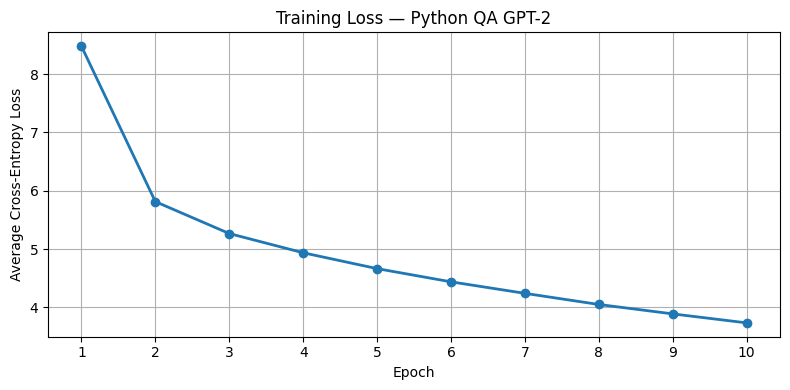

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history) + 1), history, marker='o', linewidth=2)
plt.title("Training Loss — Python QA GPT-2")
plt.xlabel("Epoch")
plt.ylabel("Average Cross-Entropy Loss")
plt.xticks(range(1, len(history) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

### 7. Generate Text from a Saved GPT-2 Checkpoint

1. **Load model and tokenizer**
   - Restore the model and tokenizer from a saved checkpoint (e.g., epoch 5).

2. **Define generation function**
   - Encodes input text with attention masks.
   - Uses `model.generate` to produce a continuation up to `max_len`.

3. **Run examples**
   - Generate Python answer snippets for several starting prompts.


In [7]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel

model_directory = "/content/drive/MyDrive/PythonGPT/model/pythongpt2_epoch5"

tokenizer = GPT2Tokenizer.from_pretrained(model_directory)
model     = GPT2LMHeadModel.from_pretrained(model_directory)
model.eval()


def generate(input_text, max_len=80):
    tokenizer.pad_token = tokenizer.eos_token

    inputs = tokenizer(
        input_text,
        return_tensors        = 'pt',
        padding               = True,
        return_attention_mask = True
    )

    output = model.generate(
        input_ids      = inputs['input_ids'],
        attention_mask = inputs['attention_mask'],
        max_length     = max_len,
        no_repeat_ngram_size = 2,
        pad_token_id   = tokenizer.eos_token_id
    )

    return tokenizer.decode(output[0], skip_special_tokens=True)


# Sample prompts — raw generation from the custom-trained checkpoint
print(generate("Question: How do you write a for loop in Python? Answer:"))
print()
print(generate("Question: What is a Python list comprehension? Answer:"))
print()
print(generate("Question: How do you handle exceptions in Python? Answer:"))
print()
print(generate("Question: How do you open a file in Python? Answer:"))
print()
print(generate("Question: What is the difference between a list and a tuple? Answer:"))

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

Question: How do you write a for loop in Python? Answer:Sure Here the of in: '.'s you a of of:',** ' ****. is to a in.:. can a that a.' ' It a to the.' "'s to to,- can used a. ' The of.'',- is.'. the is,* can the to.' the

Question: What is a Python list comprehension? Answer:Sure Here the between and.'s difference a of in: '.:',** ' ****. is to a in.**:**',- is in is.' ' It a that a.' "'s to the of that the.'',* is and a and.'. can used a- can a to to.' the is,

Question: How do you handle exceptions in Python? Answer:Sure Here the of in: '.'s you use to a of to the between and.:',** ' ****. is to to and to an of. '',- is in. can a. the.. are to function a to.() to,- can the function,* can used the.' ' The function

Question: How do you open a file in Python? Answer:Sure Here the of in: '.'s you a of to a in.:',** '',- is to the between. is in of. ' ****.() to to an of that the. the is.' ' The of of.' "'s to,**:. can the.'',* can used the function

Question: What is the difference bet

### 8. Code-Focused Inference with Python-Only Filtering

**Assignment core task** — implement the complete filtering + generation pipeline:

1. **Load Model and Tokenizer:** Load the custom-trained GPT-2 model and its tokenizer from the best checkpoint.
2. **Implement a Filtering Mechanism:** Use keyword-based prompt inspection to determine if the input is a Python coding question.
   - A prompt is considered Python-related if it contains Python keywords, built-in names, or common programming terms.
3. **Generate Response:** If the prompt is deemed a Python coding question, wrap it as `Question: <prompt> Answer:` and generate a response.
4. **Handle Non-Coding Questions:** If the prompt is not related to Python coding, return a predefined refusal message.
5. **Test:** Multiple prompts covering Python questions, general programming, and completely off-topic queries.


In [8]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch

# ── 1. Load model & tokenizer from best checkpoint ─────────────────────────
model_directory = "/content/drive/MyDrive/PythonGPT/model/pythongpt2_epoch5"

tokenizer = GPT2Tokenizer.from_pretrained(model_directory)
tokenizer.pad_token = tokenizer.eos_token

model = GPT2LMHeadModel.from_pretrained(model_directory)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()


# ── 2. Python coding keyword filter ───────────────────────────────────────
PYTHON_KEYWORDS = {
    # Language keywords
    "python", "def", "class", "import", "lambda", "yield", "return",
    "print", "range", "list", "dict", "tuple", "set", "str", "int",
    "float", "bool", "len", "type", "isinstance", "enumerate",
    "zip", "map", "filter", "sorted", "reversed",
    # Concepts
    "loop", "function", "variable", "exception", "error", "module",
    "package", "library", "object", "method", "attribute", "inheritance",
    "decorator", "generator", "comprehension", "recursion", "iterator",
    "file", "string", "integer", "boolean", "index", "slice",
    "argument", "parameter", "keyword", "syntax", "indentation",
    "pip", "pandas", "numpy", "matplotlib", "flask", "django",
    "code", "script", "program", "algorithm", "data structure",
    "array", "stack", "queue", "hash", "binary", "sort", "search",
    "write", "read", "open", "close", "append", "insert", "remove",
    "if", "else", "elif", "while", "for", "try", "except", "with", "as",
}

def is_python_question(prompt: str) -> bool:
    """
    Returns True if the prompt appears to be a Python / coding question.
    Strategy: lowercase token overlap with a curated Python keyword set.
    """
    tokens = set(re.sub(r'[^a-zA-Z0-9\s]', ' ', prompt.lower()).split())
    return bool(tokens & PYTHON_KEYWORDS)


# ── 3 & 4. Generate or refuse ──────────────────────────────────────────────
REFUSAL_MSG = (
    "I'm a Python coding assistant and can only answer questions related to "
    "Python programming. Please ask me something about Python!"
)

def answer_python_question(prompt: str, max_len: int = 100) -> str:
    """
    Filters the prompt and either generates a Python-focused answer
    or returns the refusal message for off-topic queries.
    """
    if not is_python_question(prompt):
        return REFUSAL_MSG

    # Wrap in Q&A format — same template seen during training
    formatted = f"Question: {prompt.strip()} Answer:"

    inputs = tokenizer(
        formatted,
        return_tensors        = "pt",
        padding               = True,
        return_attention_mask = True
    )
    input_ids      = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    with torch.no_grad():
        output = model.generate(
            input_ids            = input_ids,
            attention_mask       = attention_mask,
            max_length           = max_len,
            no_repeat_ngram_size = 2,
            pad_token_id         = tokenizer.eos_token_id
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)


# ── 5. Test with diverse prompts ──────────────────────────────────────────
test_prompts = [
    # ✅ Python coding questions
    "How do you write a for loop in Python?",
    "What is a list comprehension in Python?",
    "How do you define a function using def?",
    "How do you handle exceptions with try and except?",
    "What is the difference between a list and a tuple?",
    "How do you open and read a file in Python?",
    # Non-coding / off-topic questions
    "What is the capital of France?",
    "Tell me a joke.",
    "What is the best recipe for pasta?",
    "Who won the FIFA World Cup in 2022?",
]

print("=" * 70)
for prompt in test_prompts:
    print(f"\nPROMPT  : {prompt}")
    print(f"RESPONSE: {answer_python_question(prompt)}")
    print("-" * 70)

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]


PROMPT  : How do you write a for loop in Python?
RESPONSE: Question: How do you write a for loop in Python? Answer:Sure Here the of in: '.'s you a of of:',** ' ****. is to a in.:. can a that a.' ' It a to the.' "'s to to,- can used a. ' The of.'',- is.'. the is,* can the to.' the function a,**: "**',* is in.',, - the and the in,
----------------------------------------------------------------------

PROMPT  : What is a list comprehension in Python?
RESPONSE: Question: What is a list comprehension in Python? Answer:Sure Here the between and.'s difference a of in: '.:',** ' ****. is to a in.**:. are to the of that a to to an of to,- is.' ' It a.' "'s you to and.'..() to.'',- can used a that the.' the is,* is in.',**',* can a. can the and to be to function
----------------------------------------------------------------------

PROMPT  : How do you define a function using def?
RESPONSE: Question: How do you define a function using def? Answer:Sure Here the of in: '.'s you a of to a in.:',

Outcome : I was unable to find the relevant dataset for the python question answer but it is still able to give the answer according to the dataset and also able to differentiate between python related and different topic questions